In [9]:
import json
import pickle
import re
import sqlite3
import string
import time
import csv
from collections import defaultdict

import pandas as pd
import numpy as np
from elasticsearch import Elasticsearch, helpers
from elasticsearch.helpers import scan
from tqdm import tqdm

In [2]:
df = pd.read_csv("../../data/processed/pubchem/CID-Synonym-cleaned-common-cid-no-four-digits.tsv", sep="\t")
synonym = df['Synonym'].tolist()

In [3]:
cid_date_path = "../../data/processed/pubchem/cid_date.pkl"
with open(cid_date_path, "rb") as f:
    cid_date = pickle.load(f)

In [ ]:
import csv
ES_HOST = "http://elasticsearch:9200"
ES_PASSWORD = "micgm1Gemini"
es = Elasticsearch(ES_HOST, basic_auth=("elastic", ES_PASSWORD))

output_path = "../term_pmid_pubyear.csv"
fieldnames = ["term", "PMID", "PUB_YEAR", "PUB_MONTH"]

f = open(output_path, mode='w', newline='', encoding='utf-8')
writer = csv.DictWriter(f, fieldnames=fieldnames)
writer.writeheader()

for i in tqdm(range(len(synonym))):
    if i == 1:break
    query_word = synonym[i]

    search_body = { 
        "query": { 
            "multi_match": { 
                "query": query_word, 
                "fields": ["ABST"], 
                "type": "phrase" 
            } 
        }, 
        "sort": [ 
            {"PUB_YEAR": {"order": "asc"}},
            {"PUB_MONTH": {"order": "asc"}},
            {"PMID": {"order": "asc"}}, 
        ], 
        "_source": ["PMID", "PUB_YEAR", "PUB_MONTH"],
        "size": 1 
    }

    try:
        res = es.search(index="pubmed_v2", body=search_body)
        hits = res['hits']['hits']

        if len(hits) > 0:
            top_hit = hits[0] 
            source = top_hit['_source']
            
            row = {
                "term": query_word,
                "PMID": source.get('PMID'),
                "PUB_YEAR": source.get('PUB_YEAR'),
                "PUB_MONTH": source.get('PUB_MONTH')
            }
            writer.writerow(row)
            
    except Exception as e:
        print(f"Error searching for {query_word}: {e}")

f.close()
print("Done.")

  0%|          | 1/6013397 [00:00<148:33:48, 11.24it/s]

Error searching for Acetyl-DL-carnitine: dict contains fields not in fieldnames: 'PUB_MONTH'
Done.


In [4]:
df_result = pd.read_csv("/workspace/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/processed/pubmed/term_pmid_pubyear.csv")

In [5]:
df_result.head()

,term,PMID,PUB_YEAR
0,"4,4,5,5-tetramethyl-2,3-dihydroxy-2-cyclopente...",17579400,2007
1,3-(1H-indol-3-yl)propanehydrazide,23567956,2013
2,Oflocet,2696066,1989
3,1-butyl-3-methylimidazolium azide,18624414,2008
4,2-furaldehyde-2-pyridylhydrazone,18963928,1985


In [6]:
print(len(df_result))

285571


In [20]:
pmid_date_dict = {}
for _, row in df_year.iterrows():
    pmid = row['PMID']
    pub_year = row['PUB_YEAR']
    pub_month = row['PUB_MONTH']
    pmid_date_dict[pmid] = (pub_year, pub_month)

In [11]:
ES_HOST = "http://elasticsearch:9200"
ES_PASSWORD = "micgm1Gemini"
es = Elasticsearch(ES_HOST, basic_auth=("elastic", ES_PASSWORD))

output_path = "../term_pmid_pubyear.csv"
fieldnames = ["PMID", "PUB_YEAR", "PUB_MONTH"]
CHUNK_SIZE = 1000 

f = open(output_path, mode='w', newline='', encoding='utf-8')
writer = csv.DictWriter(f, fieldnames=fieldnames)
writer.writeheader()

PMID_LIST = list(set(df_result['PMID'].tolist()))
total_pmids = len(PMID_LIST)

for i in tqdm(range(0, total_pmids, CHUNK_SIZE)):
    batch_pmids = PMID_LIST[i : i + CHUNK_SIZE]
    search_body = {
        "query": {
            "terms": {
                "PMID": batch_pmids
            }
        },
        "_source": ["PMID", "PUB_YEAR", "PUB_MONTH"],
        "size": CHUNK_SIZE 
    }

    res = es.search(index="pubmed_v2", body=search_body)
    hits = res['hits']['hits']
    
    row_list = []
    for hit in hits:
        source = hit['_source']
        pmid_val = source.get('PMID')
        
        row_list.append({
            "PMID": pmid_val,
            "PUB_YEAR": source.get('PUB_YEAR'),
            "PUB_MONTH": source.get('PUB_MONTH')
        })
        
    writer.writerows(row_list)


if 'f' in locals() and not f.closed:
    f.close()

100%|██████████| 187/187 [00:19<00:00,  9.74it/s]


In [13]:
df_year = pd.read_csv(output_path)
df_year.head()

,PMID,PUB_YEAR,PUB_MONTH
0,26738699,2016,1
1,26739592,2016,12
2,26739896,2016,1
3,26740458,2016,1
4,26740544,0,0


In [14]:
print(len(df_year))

186442


In [15]:
pmid_date_dict = {}
for _, row in df_year.iterrows():
    pmid = row['PMID']
    pub_year = row['PUB_YEAR']
    pub_month = row['PUB_MONTH']
    pmid_date_dict[pmid] = (pub_year, pub_month)

In [16]:
# df_result['PUB_YEAR'] = df_result['PMID'].map(lambda x: pmid_date_dict.get(x, (None, None))[0])
df_result['PUB_MONTH'] = df_result['PMID'].map(lambda x: pmid_date_dict.get(x, (None, None))[1])

In [17]:
df_result

,term,PMID,PUB_YEAR,PUB_MONTH
0,"4,4,5,5-tetramethyl-2,3-dihydroxy-2-cyclopente...",17579400,2007,7
1,3-(1H-indol-3-yl)propanehydrazide,23567956,2013,5
2,Oflocet,2696066,1989,12
3,1-butyl-3-methylimidazolium azide,18624414,2008,8
4,2-furaldehyde-2-pyridylhydrazone,18963928,1985,10
...,...,...,...,...
285566,acetylthymine,1587345,1992,5
285567,Tetcyclacis,16663977,1984,12
285568,Dilaurylphosphatidylcholine,11780930,0,0
285569,10-oxo-12(Z)-octadecenoic acid,10858019,2000,4


In [23]:
df_result.to_csv(output_path, index=False)

In [18]:
from datetime import datetime, timedelta
import math

def decimal_year_to_yyyymmdd(decimal_year):
    year = int(decimal_year)
    fraction = decimal_year - year
    start_of_year = datetime(year, 1, 1)
    days_in_year = (datetime(year + 1, 1, 1) - start_of_year).days
    delta_seconds = fraction * days_in_year * 86400
    target_date = start_of_year + timedelta(seconds=delta_seconds)
    return target_date.strftime('%Y%m%d')

def yyyymm_to_decimal(yyyymm):
    try:
        s = str(yyyymm)
        year = int(s[:4])
        month = int(s[4:6])
        return year + (month - 1) / 12
    except:
        return np.nan

In [19]:
synonym_use = set(df_result["term"].tolist())

In [22]:
df_filtered = df[df['Synonym'].isin(synonym_use)]
synonym_cid = df_filtered.set_index('Synonym')['CID'].to_dict()

In [23]:
df_result["CID"] = df_result["term"].map(synonym_cid)
df_result["YYYYMM"] = df_result["PUB_YEAR"].astype(str).str.zfill(4) + df_result["PUB_MONTH"].astype(str).str.zfill(2)
df_result["PUB_DATE_DECIMAL"] = df_result["YYYYMM"].apply(yyyymm_to_decimal)

In [24]:
cid_date_yyyymm = {cid: decimal_year_to_yyyymmdd(date) for cid, date in cid_date.items()}
df_result["PATENT_DATE_YYYYMM"] = df_result["CID"].map(cid_date_yyyymm)

In [25]:
df_result["PATENT_DATE_DECIMAL"] = df_result["PATENT_DATE_YYYYMM"].map(yyyymm_to_decimal)

In [26]:
df_result = df_result.dropna()

In [27]:
df_result.head()

,term,PMID,PUB_YEAR,PUB_MONTH,CID,YYYYMM,PUB_DATE_DECIMAL,PATENT_DATE_YYYYMM,PATENT_DATE_DECIMAL
0,"4,4,5,5-tetramethyl-2,3-dihydroxy-2-cyclopente...",17579400,2007,7,74682,200707,2007.500000,19800423,1980.250000
2,Oflocet,2696066,1989,12,4583,198912,1989.916667,20070301,2007.166667
5,Mercaptobenzene,4076432,1985,9,7969,198509,1985.666667,19730214,1973.083333
7,2-Hydroxyiminomethyl-N-methylpyridinium methan...,13536287,1958,6,135476791,195806,1958.416667,19930205,1993.083333
8,Budipin,10202609,0,0,68778,000000,-0.083333,19770405,1977.250000


In [28]:
print(len(df_result))

140372


In [29]:
df_result_not_zero = df_result[df_result["PUB_DATE_DECIMAL"] > 0]

In [30]:
df_result_not_zero = df_result_not_zero.sort_values(by="CID")

In [31]:
df_sorted = df_result_not_zero.sort_values("PUB_DATE_DECIMAL", ascending=True)
df_unique = df_sorted.drop_duplicates(subset=["CID"], keep="first")
df_unique = df_unique.reset_index(drop=True)

print(f"元の行数: {len(df_result_not_zero)}")
print(f"削除後の行数 (ユニークCID数): {len(df_unique)}")
df_unique.head()

元の行数: 91888
削除後の行数 (ユニークCID数): 29423


,term,PMID,PUB_YEAR,PUB_MONTH,CID,YYYYMM,PUB_DATE_DECIMAL,PATENT_DATE_YYYYMM,PATENT_DATE_DECIMAL
0,P-638,36023358,1876,9,439530,187609,1876.666667,19760310,1976.166667
1,Salol,19866955,1901,3,8361,190103,1901.166667,19740625,1974.416667
2,Chloreton,19866971,1902,3,5977,190203,1902.166667,19760114,1976.000000
3,Cholalic acid,19867284,1909,11,221493,190911,1909.833333,19741106,1974.833333
4,Phlorhizin,19867307,1910,1,6072,191001,1910.000000,19770504,1977.333333


In [35]:
X = df_unique["PUB_DATE_DECIMAL"].values
y = df_unique["PATENT_DATE_DECIMAL"].values

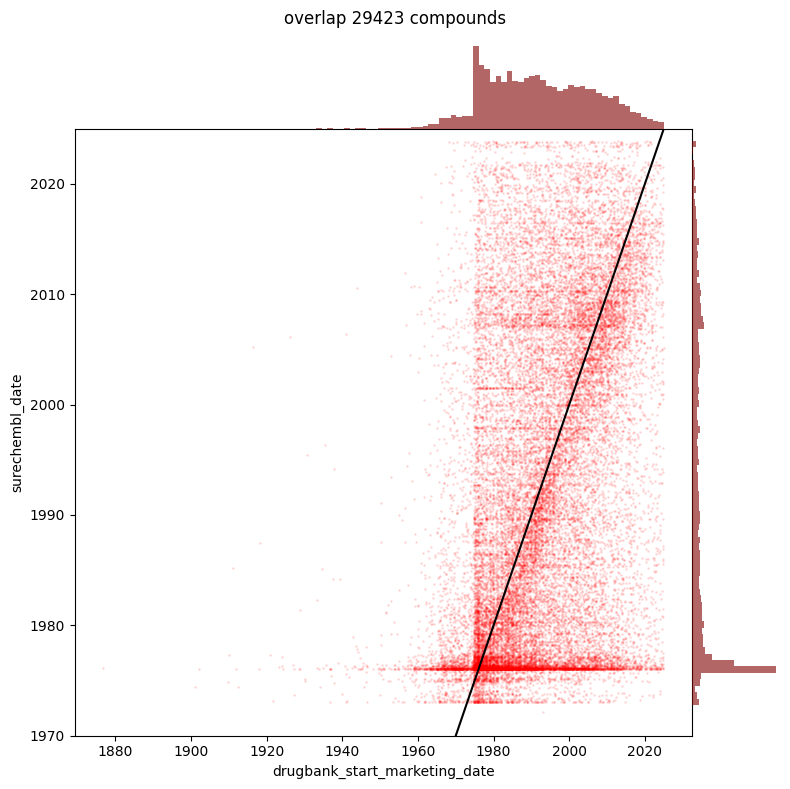

In [36]:
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
x_db = X
x_sc = y

fig = plt.figure(figsize=(8, 8))
gs = GridSpec(8, 8, figure=fig, wspace=0.0, hspace=0.0,)

scatter_ax = fig.add_subplot(gs[1:8, 0:7])
scatter_ax.scatter(x_db, x_sc, alpha=0.1, c="red", s=1)
x = np.linspace(1880, 2025 , 1000000)
y = x
scatter_ax.plot(x, y, c="black")
scatter_ax.set_ylim((1970,2025))
scatter_ax.set_xlabel('drugbank_start_marketing_date')
scatter_ax.set_ylabel("surechembl_date")

hist_x_ax = fig.add_subplot(gs[0, 0:7], sharex=scatter_ax)
hist_x_ax.hist(x_db, bins=100, alpha=0.6, color='maroon')
hist_x_ax.axis('off')

hist_y_ax = fig.add_subplot(gs[1:8, 7], sharey=scatter_ax)
hist_y_ax.hist(x_sc, bins=100, orientation='horizontal', alpha=0.6, color='maroon')
hist_y_ax.axis('off')

fig.suptitle(f"overlap {len(x_db)} compounds")
plt.tight_layout()
plt.savefig('../../data/result/fig5_overlap/surechembl_pubmed_date_vs_patent_date.png', dpi=300)

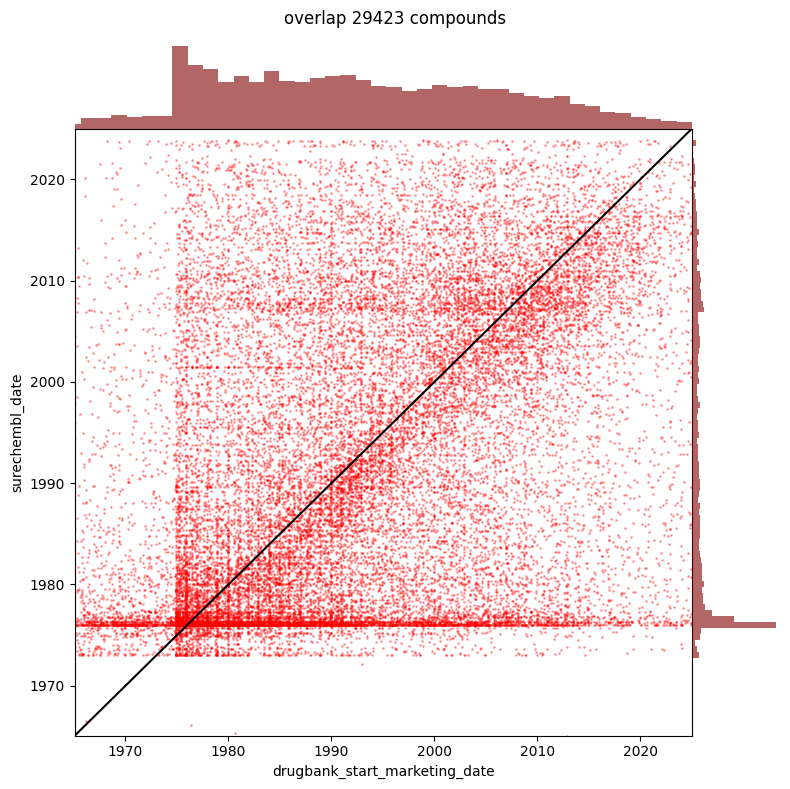

In [37]:
min_X = np.min(x_sc)

fig = plt.figure(figsize=(8, 8))
gs = GridSpec(8, 8, figure=fig, wspace=0.0, hspace=0.0,)

scatter_ax = fig.add_subplot(gs[1:8, 0:7])
scatter_ax.scatter(x_db, x_sc, alpha=0.3, c="red", s=1)

common_min = np.min(x_sc)
common_max = max(np.max(x_db), np.max(x_sc))

scatter_ax.set_xlim((common_min, common_max))
scatter_ax.set_ylim((common_min, common_max))

x_line = np.linspace(common_min, common_max, 100)
scatter_ax.plot(x_line, x_line, c="black")

scatter_ax.set_xlabel('drugbank_start_marketing_date')
scatter_ax.set_ylabel("surechembl_date")

hist_x_ax = fig.add_subplot(gs[0, 0:7], sharex=scatter_ax)
hist_x_ax.hist(x_db, bins=100, alpha=0.6, color='maroon')
hist_x_ax.axis('off')

hist_y_ax = fig.add_subplot(gs[1:8, 7], sharey=scatter_ax)
hist_y_ax.hist(x_sc, bins=100, orientation='horizontal', alpha=0.6, color='maroon')
hist_y_ax.axis('off')

fig.suptitle(f"overlap {len(x_db)} compounds")
plt.savefig('../../data/result/fig5_overlap/surechembl_pubmed_date_vs_patent_date_tiled.png', dpi=300)
plt.tight_layout()

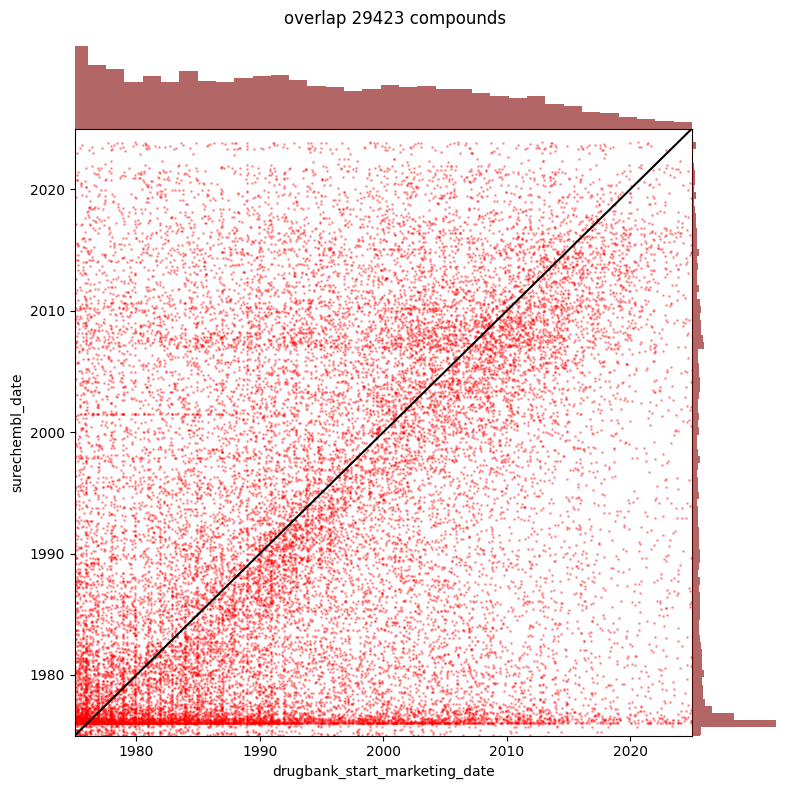

In [38]:
min_X = 1975

fig = plt.figure(figsize=(8, 8))
gs = GridSpec(8, 8, figure=fig, wspace=0.0, hspace=0.0,)

scatter_ax = fig.add_subplot(gs[1:8, 0:7])
scatter_ax.scatter(x_db, x_sc, alpha=0.3, c="red", s=1)

common_min = min_X
common_max = max(np.max(x_db), np.max(x_sc))

scatter_ax.set_xlim((common_min, common_max))
scatter_ax.set_ylim((common_min, common_max))

x_line = np.linspace(common_min, common_max, 100)
scatter_ax.plot(x_line, x_line, c="black")

scatter_ax.set_xlabel('drugbank_start_marketing_date')
scatter_ax.set_ylabel("surechembl_date")

hist_x_ax = fig.add_subplot(gs[0, 0:7], sharex=scatter_ax)
hist_x_ax.hist(x_db, bins=100, alpha=0.6, color='maroon')
hist_x_ax.axis('off')

hist_y_ax = fig.add_subplot(gs[1:8, 7], sharey=scatter_ax)
hist_y_ax.hist(x_sc, bins=100, orientation='horizontal', alpha=0.6, color='maroon')
hist_y_ax.axis('off')

fig.suptitle(f"overlap {len(x_db)} compounds")
plt.tight_layout()

plt.savefig('../../data/result/fig5_overlap/surechembl_pubmed_date_vs_patent_date_tiled_1975.png', dpi=300)

In [ ]:
correlation = np.corrcoef(x_db, x_sc)[0, 1]
print(f"Correlation coefficient: {correlation:.4f}")

# rank correlatio
from scipy.stats import rankdata
x_db_rank = rankdata(x_db)
x_sc_rank = rankdata(x_sc)
correlation = np.corrcoef(x_db_rank, x_sc_rank)[0, 1]
print(f"Spearman rank Correlation coefficient: {correlation:.4f}")

# Percentage of compounds whose patents were filed earlier, based on data from 1976 onward when US patent information began to be collected
filtered_indices = [i for i, x in enumerate(x_sc) if x > 1976]
smaller_count = sum(x_sc[i] < x_db[i] for i in filtered_indices)
total_count = len(filtered_indices)
smaller_ratio = smaller_count / total_count
print(f"Ratio of data where Shurechembl is faster than drugbank: {smaller_ratio:.4%}")

Correlation coefficient: 0.4076
Spearman rank Correlation coefficient: 0.4188
Ratio of data where Shurechembl is faster than drugbank: 49.3947%


In [ ]:
filtered_indices = [i for i, x in enumerate(x_sc) if x > 1980]
within_5y_count = sum(abs(x_sc[i] - x_db[i]) <= 5 for i in filtered_indices)

total_count = len(filtered_indices)
within_5y_ratio = within_5y_count / total_count

print(f"Ratio of data appearing within ±5 years: {within_5y_ratio:.4%}")

Ratio of data appearing within ±5 years: 35.0773%
